# Exercise 4: Forecast diabetes progression

This notebook follows the subject wording literally: the dataset is loaded from
`sklearn.datasets.load_diabetes(as_frame=True)`, then split into train and test
parts, fitted with `LinearRegression`, evaluated with train and test MSE, and
visualized with prediction and residual plots.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")

def compute_mse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.mean((y_true - y_pred) ** 2)

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target
feature_names = list(X.columns)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=43,
)

print(y_train.values[:10])
print(y_test.values[:10])


[202.  55. 202.  42. 214. 173. 118.  90. 129. 151.]
[ 71.  72. 235. 277. 109.  61. 109.  78.  66. 192.]


In [3]:
model = LinearRegression().fit(X_train, y_train)

coefficients_and_intercept = [(name, float(value)) for name, value in zip(feature_names, model.coef_)]
coefficients_and_intercept.append(("intercept", float(model.intercept_)))

print(coefficients_and_intercept)


[('age', -60.399848093336004), ('sex', -226.08359044269196), ('bmi', 529.3849571887339), ('bp', 259.9619941214206), ('s1', -859.0930093348031), ('s2', 504.6869733896196), ('s3', 157.41085788032822), ('s4', 226.2931343552116), ('s5', 840.7840406049226), ('s6', 34.71226555571708), ('intercept', 152.0532454782767)]


In [4]:
predictions_on_train = model.predict(X_train).reshape(-1, 1)
predictions_on_test = model.predict(X_test).reshape(-1, 1)

train_mse = compute_mse(y_train, predictions_on_train)
test_mse = compute_mse(y_test, predictions_on_test)

print(repr(predictions_on_test[:10]))
print(f"Train MSE: {train_mse:.6f}")
print(f"Test MSE: {test_mse:.6f}")


array([[111.74267934],
       [ 98.41608992],
       [168.36714629],
       [255.06351455],
       [168.44138847],
       [117.60698984],
       [198.8733865 ],
       [126.2932775 ],
       [117.72876579],
       [224.82776308]])
Train MSE: 2888.324598
Test MSE: 2858.291506


The `y_true vs y_pred` plots are a quick visual check: points close to the
diagonal are predicted well, while larger spread means larger regression error.


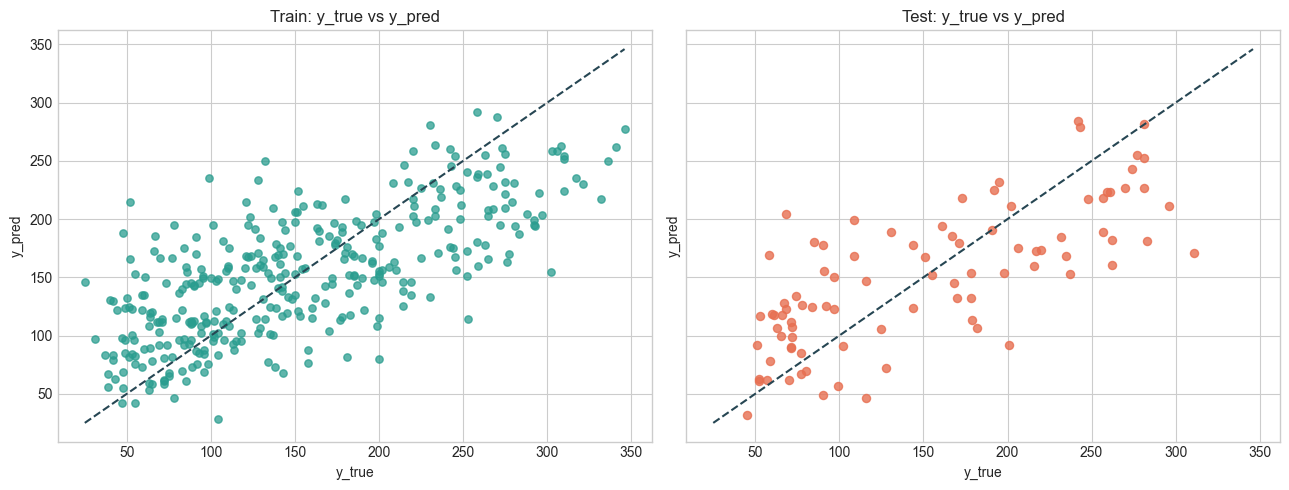

In [5]:
train_pred = predictions_on_train.ravel()
test_pred = predictions_on_test.ravel()
diagonal_min = min(y_train.min(), y_test.min(), train_pred.min(), test_pred.min())
diagonal_max = max(y_train.max(), y_test.max(), train_pred.max(), test_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(y_train, train_pred, s=28, color="#2a9d8f", alpha=0.75)
axes[0].plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="#264653", linestyle="--")
axes[0].set(title="Train: y_true vs y_pred", xlabel="y_true", ylabel="y_pred")

axes[1].scatter(y_test, test_pred, s=34, color="#e76f51", alpha=0.8)
axes[1].plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="#264653", linestyle="--")
axes[1].set(title="Test: y_true vs y_pred", xlabel="y_true", ylabel="y_pred")

fig.tight_layout()
plt.show()


Residual plots complement the prediction view: values centered around zero with no
obvious trend usually indicate that the linear model is behaving reasonably.


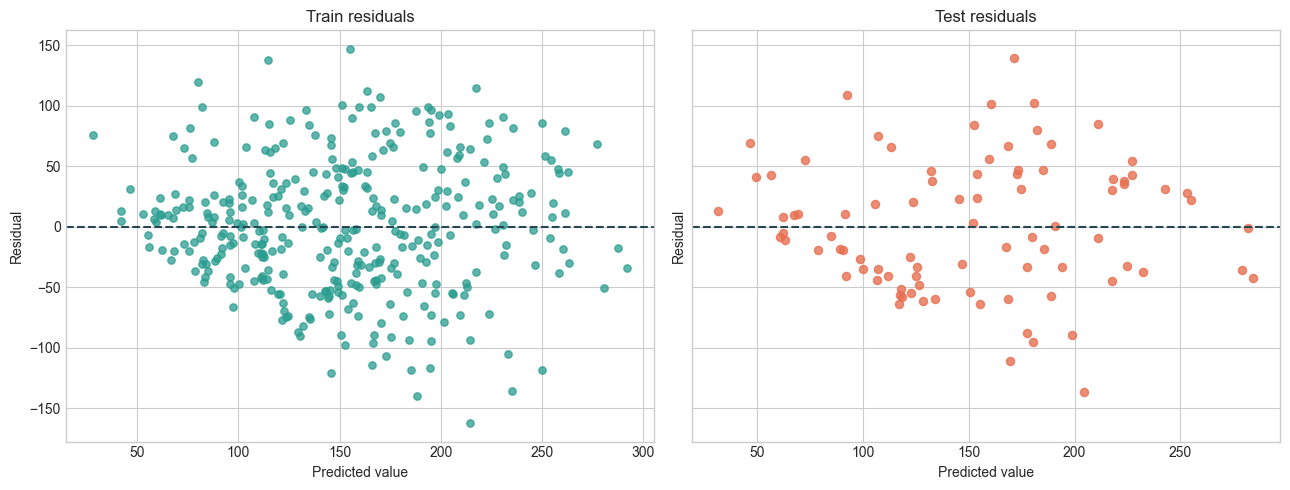

In [6]:
train_residuals = y_train.to_numpy() - train_pred
test_residuals = y_test.to_numpy() - test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].scatter(train_pred, train_residuals, s=28, color="#2a9d8f", alpha=0.75)
axes[0].axhline(0.0, color="#264653", linestyle="--")
axes[0].set(title="Train residuals", xlabel="Predicted value", ylabel="Residual")

axes[1].scatter(test_pred, test_residuals, s=34, color="#e76f51", alpha=0.8)
axes[1].axhline(0.0, color="#264653", linestyle="--")
axes[1].set(title="Test residuals", xlabel="Predicted value", ylabel="Residual")

fig.tight_layout()
plt.show()


The dataset source remains simple and explicit: `load_diabetes(as_frame=True)` is
the only source of data used by the notebook.
